# Практическое занятие №4

## Случайные сигналы, шумы и спектральная плотность мощности

## Задание 1. Генерация белого, розового и красного шума
Сгенерируйте три сигнала длительностью 2 секунды с частотой дискретизации 1000 Гц:
- Белый гауссов шум с нулевым средним и дисперсией 1.
- Розовый шум – возьмите Фурье-преобразование от белого шума, домножьте его на функцию $1/\sqrt{f}$ и возьмите обратное Фурье-преобразование, результат нормализуйте.
- красный шум – кумулятивная сумма белого шума (нормалиованная).

Постройте временные графики всех трёх сигналов. Вычислите и выведите их средние значения и дисперсии.


In [38]:
import numpy as np
import matplotlib.pyplot as plt

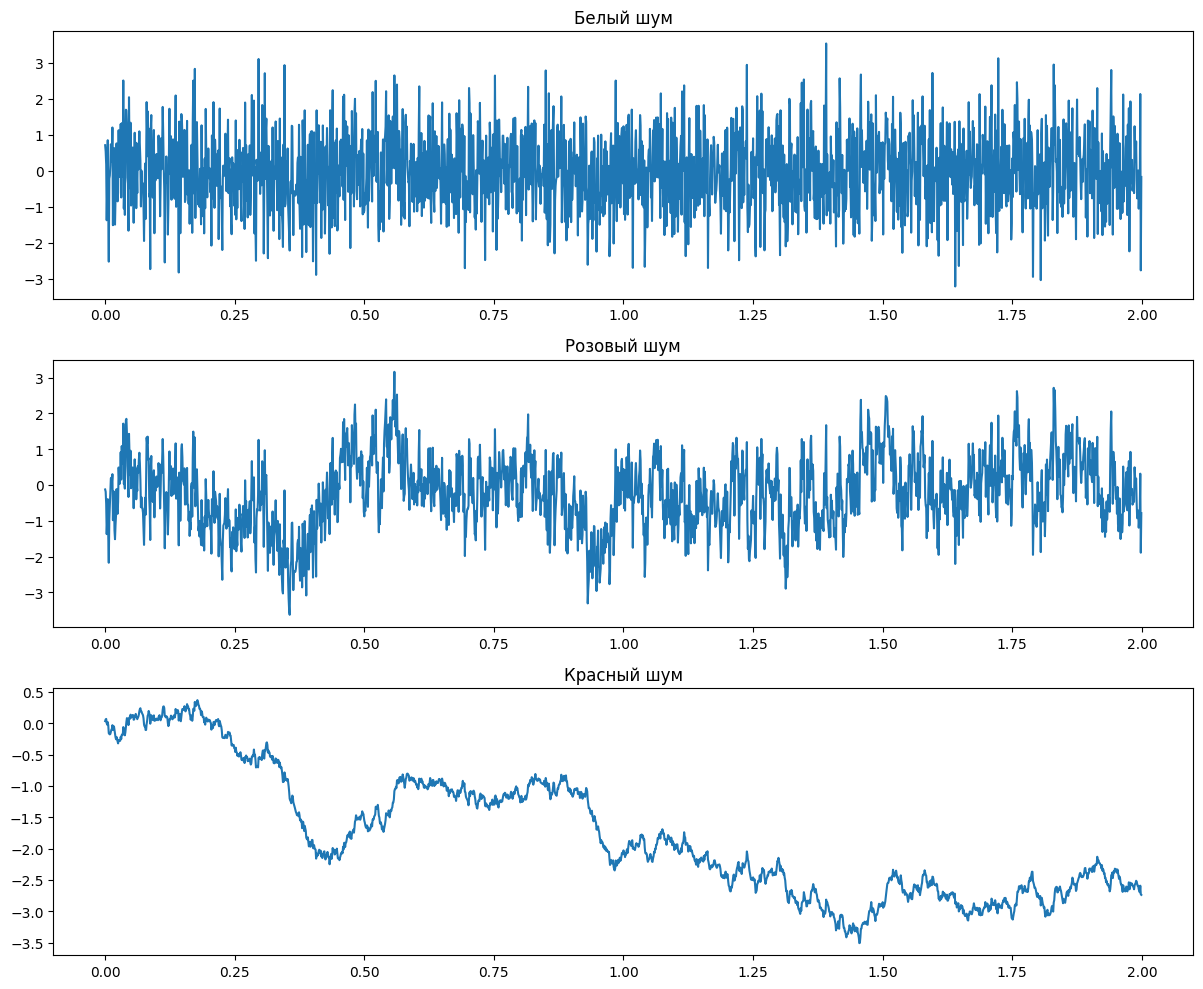

Среднее: белый=-0.028, розовый=-0.231, красный=-1.760
Дисперсия: белый=1.073, розовый=1.000, красный=1.000


In [39]:
fs = 1000
T = 2
N = fs * T
t = np.arange(N) / fs

white = np.random.normal(0, 1, N)

white_fft = np.fft.rfft(white)
freqs = np.fft.rfftfreq(N, d=1/fs)

spec = np.fft.rfft(white)
freqs = np.fft.rfftfreq(N, 1/fs)
spec[1:] /= np.sqrt(freqs[1:])
pink = np.fft.irfft(spec)
pink = pink / np.std(pink)

red = np.cumsum(white)
red = red / np.std(red)
plt.figure(figsize=(12,10))
plt.subplot(3,1,1)
plt.plot(t, white), plt.title('Белый шум')
plt.subplot(3,1,2)
plt.plot(t, pink), plt.title('Розовый шум')
plt.subplot(3,1,3)
plt.plot(t, red), plt.title('Красный шум')
plt.tight_layout()
plt.show()

print(f'Среднее: белый={white.mean():.3f}, розовый={pink.mean():.3f}, красный={red.mean():.3f}')
print(f'Дисперсия: белый={white.var():.3f}, розовый={pink.var():.3f}, красный={red.var():.3f}')

**Вопрос:** Как визуально отличаются разные виды шума? Совпадают ли вычисленные средние и дисперсии сигналов от теоретических? Если отличаются, объясните почему.


{Белый - частые скачки, розовый - скачки чуть реже и их количество меньше. Красный - незначительные редкие скачки, срадние у красного не близка к 0, в отличие от белого и розового, у которых приближено к 0. Дисперсия у всех близка к 1. Такое отличие у красного появляется из-за того, что у него случайная начальная точка, но все равно некоторые средние значения могут быть близки к 0}

## Задание 2. Вычисление автокорреляционной функции (АКФ)
Для каждого из сгенерированных шумов вычислите автокорреляционную функцию (с помощью `np.correlate(x, x, mode='full')`). Возьмите только положительные сдвиги (или сдвиги от -N+1 до N-1, но визуализируйте симметричную часть). Постройте графики нормированных АКФ (поделите на значение при нулевом сдвиге) для всех трёх шумов на одном рисунке.


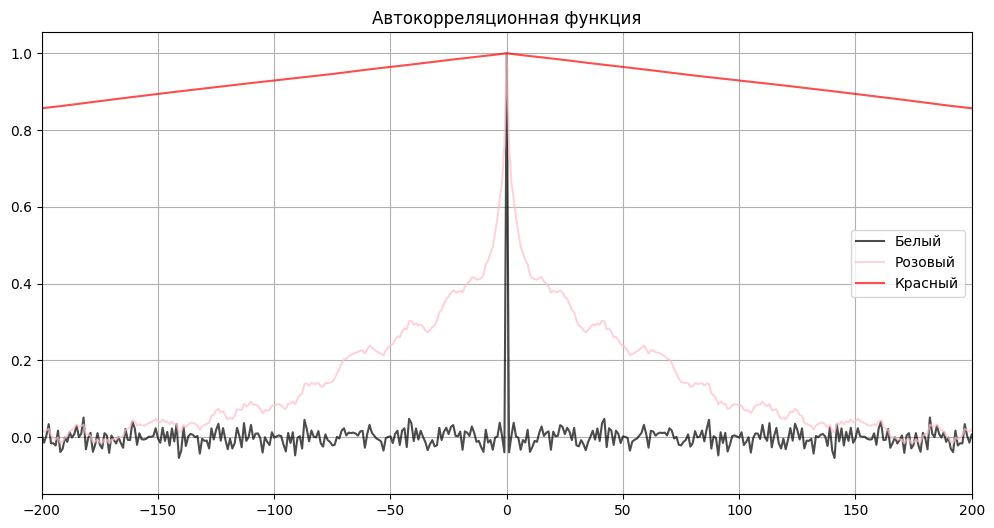

In [40]:
def autocorr(x):
    corr = np.correlate(x, x, mode='full')
    corr = corr / corr[len(x)-1]
    lags = np.arange(-len(x)+1, len(x))
    return lags, corr

plt.figure(figsize=(12,6))
for color, sig, name in zip(['black','pink','red'], [white, pink, red], ['Белый','Розовый','Красный']):
    lags, corr = autocorr(sig)
    plt.plot(lags, corr, color=color, label=name, alpha=0.7)
plt.xlim(-200,200)
plt.grid(), plt.legend(), plt.title('Автокорреляционная функция')
plt.show()

**Вопрос:** Сравнив АКФ и временную развёртку для разных видов шума, сделайте вывод о том, как форма АКФ связана с гладкостью сигнала.


{У белого шума АКФ очень быстро идет к 0, поэтому он такой резкий. АКФ у розового шире, поэтому менее резко менятся. У красного самый широкий АКФ, поэтому он менее изменчивый и резкий. Вывод: чем шум более гладкий и менее резкий, тем шире график АКФ и тем медленнее она спадает}

## Задание 3. Оценка спектральной плотности мощности (СПМ). Периодограмма и метод Уэлча
Для каждого типа шума вычислите:
- Периодограмму с помощью `scipy.signal.periodogram`.
- Оценку СПМ методом Уэлча с помощью `scipy.signal.welch` с параметрами `nperseg=256`, `noverlap=128`, окно Ханна.

Постройте на одном графике (для каждого шума отдельно) периодограмму и оценку Уэлча в двойном логарифмическом масштабе по оси Y (используйте `plt.loglog`).


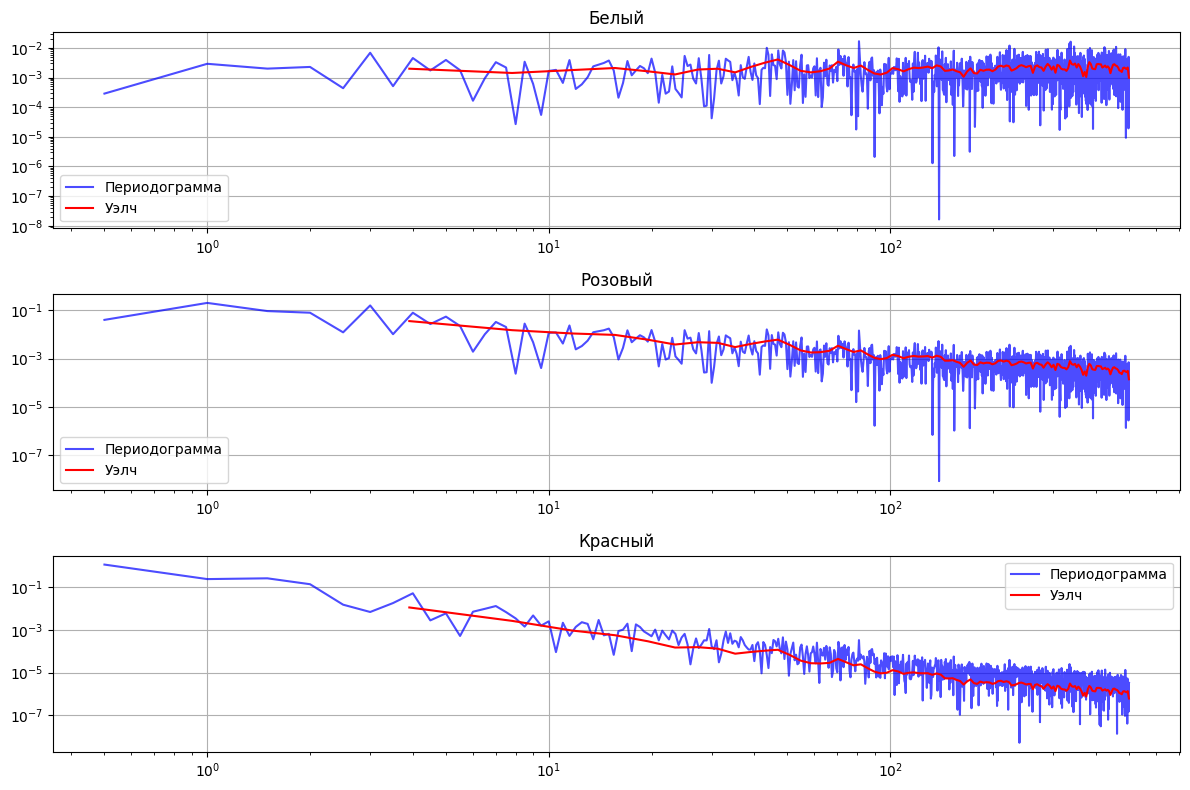

In [41]:
from scipy.signal import periodogram, welch

plt.figure(figsize=(12,8))
for i, (sig, name) in enumerate(zip([white, pink, red], ['Белый','Розовый','Красный'])):
    f_per, P_per = periodogram(sig, fs)
    f_wel, P_wel = welch(sig, fs, nperseg=256, noverlap=128, window='hann')
    plt.subplot(3,1,i+1)
    plt.loglog(f_per[1:], P_per[1:], 'blue', alpha=0.7, label='Периодограмма')
    plt.loglog(f_wel[1:], P_wel[1:], 'r', label='Уэлч')
    plt.title(name)
    plt.legend(), plt.grid()
plt.tight_layout()
plt.show()

**Вопрос:** Как выглядят зависимости СПМ от частоты у разных видов шума в двойном логарифмическом масштабе? Как они должны выглядеть теоретически?


{Белый - горизонтальная линия. это означает, что мощность примерно одинаковая на всех частотах. В теории S(f) = константа, что соответствует графику. Розовый - прямая линия с равномерным спадом. В теории S(f)∼1/f, что соответствует графику. Красный тоже прямая линия с равномерным спадом, но более сильным, чем у розового шума. В теории S(f)∼1/f, что соответствует графику.}

## Задание 4. Влияние длины сегмента в методе Уэлча
Для белого шума вычислите оценку СПМ методом Уэлча с разной длиной сегмента: `nperseg = 64, 128, 256, 512`. Используйте окно Ханна, перекрытие 50%. Постройте все четыре оценки на одном графике (логарифмическая шкала по Y).


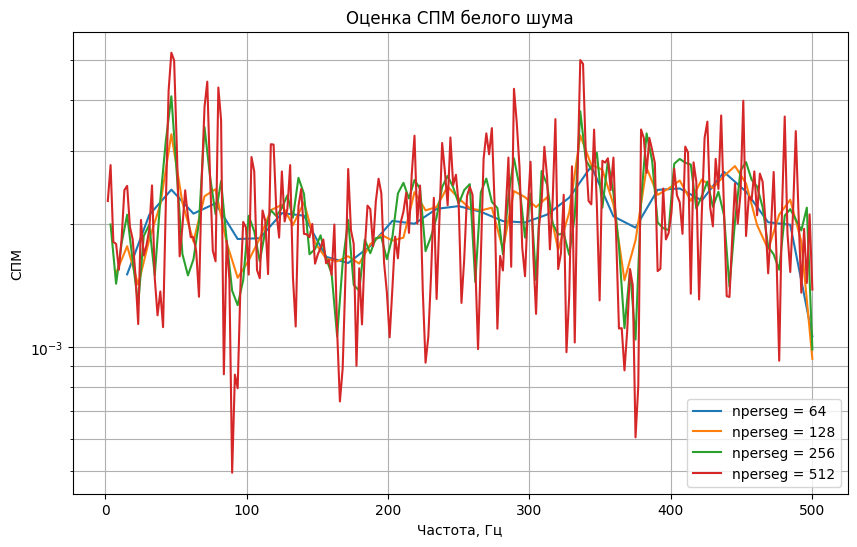

In [42]:
nperseg_values = [64, 128, 256, 512]

plt.figure(figsize=(10, 6))

for nperseg in nperseg_values:
    f, Pxx = welch(
        white,
        fs=fs,
        window='hann',
        nperseg=nperseg,
        noverlap=nperseg // 2
    )
    plt.semilogy(f[1:], Pxx[1:], label=f'nperseg = {nperseg}')

plt.title('Оценка СПМ белого шума')
plt.xlabel('Частота, Гц')
plt.ylabel('СПМ')
plt.grid(True, which='both')
plt.legend()
plt.show()

**Вопрос:** Как увеличение длины сегмента влияет на разрешение по частоте (ширину пиков) и гладкость оценки (дисперсию значений)?


{При увеличении длины сегмента частота пиков увеличивается, но гладкость оценки уменьшается, и наоборот}

## Задание 5. Влияние дисперсии шума на его характеристики
Для каждого вида шума вычислите и выведите на один график при разных значениях дисперсии (например, 0.1, 1, 10):
1. Временную реализацию.
2. АКФ.
3. СПМ.

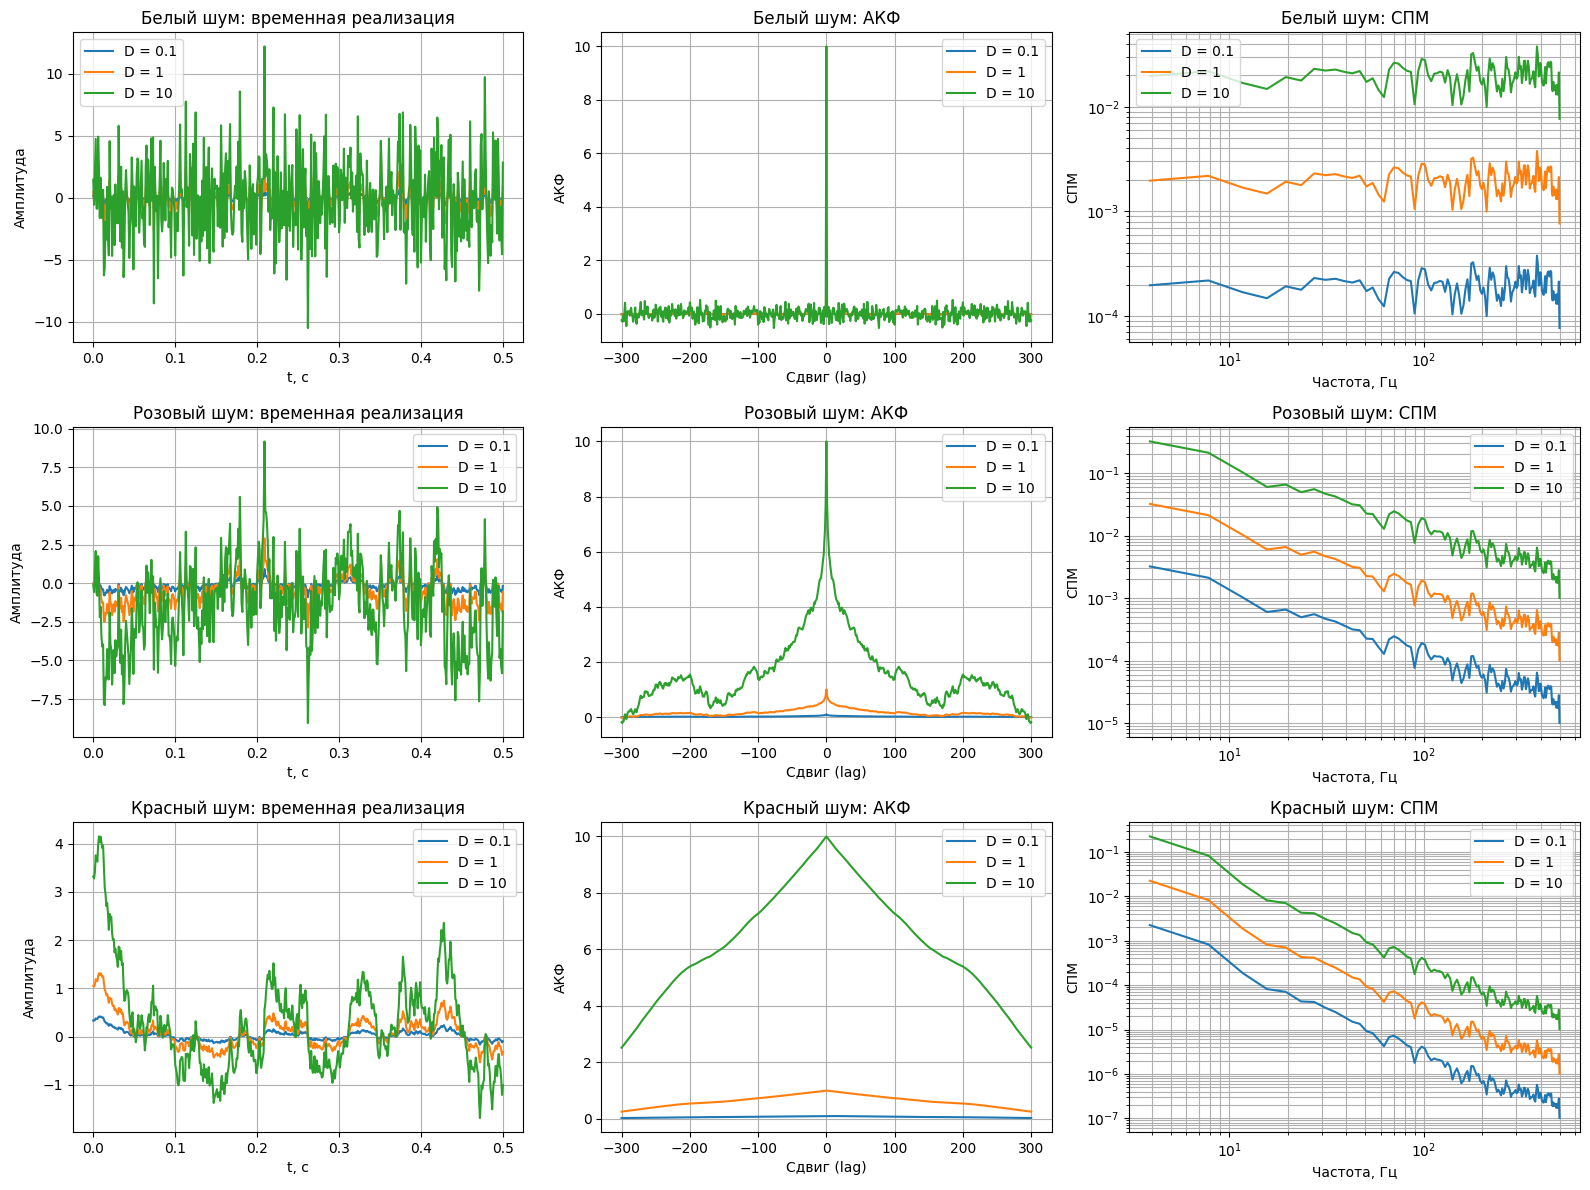

In [43]:
np.random.seed(42)

fs = 1000
T = 2.0
N = int(fs * T)

base_white = np.random.normal(0, 1, N)
base_white = (base_white - np.mean(base_white)) / np.std(base_white)

spec = np.fft.rfft(base_white)
freqs = np.fft.rfftfreq(N, d=1/fs)
pink_filt = np.ones_like(freqs)
pink_filt[1:] = 1 / np.sqrt(freqs[1:])
pink_filt[0] = 0
spec_pink = spec * pink_filt
base_pink = np.fft.irfft(spec_pink, n=N)
base_pink = (base_pink - np.mean(base_pink)) / np.std(base_pink)

base_red = np.cumsum(base_white)
base_red = (base_red - np.mean(base_red)) / np.std(base_red)

def acf_raw(x, max_lag=300):
    acf = np.correlate(x, x, mode='full') / len(x)
    lags = np.arange(-len(x) + 1, len(x))
    mask = np.abs(lags) <= max_lag
    return lags[mask], acf[mask]

fs = 1000
T = 2.0
N = int(fs * T)
t = np.arange(N) / fs
variances = [0.1, 1, 10]

plt.figure(figsize=(16, 12))

row = 0
name = "Белый шум"
base_signal = base_white

plt.subplot(3, 3, row*3 + 1)
plt.subplot(3, 3, row*3 + 2)
plt.subplot(3, 3, row*3 + 3)

for var in variances:
    x = base_signal * np.sqrt(var)

    plt.subplot(3, 3, row*3 + 1)
    mask_t = t <= 0.5
    plt.plot(t[mask_t], x[mask_t], label=f'D = {var}')

    plt.subplot(3, 3, row*3 + 2)
    lags, acf_vals = acf_raw(x, max_lag=300)
    plt.plot(lags, acf_vals, label=f'D = {var}')

    plt.subplot(3, 3, row*3 + 3)
    f, Pxx = welch(x, fs=fs, nperseg=256, noverlap=128, window='hann')
    plt.loglog(f[1:], Pxx[1:], label=f'D = {var}')

plt.subplot(3, 3, row*3 + 1)
plt.title(f'{name}: временная реализация')
plt.xlabel('t, c')
plt.ylabel('Амплитуда')
plt.grid()
plt.legend()

plt.subplot(3, 3, row*3 + 2)
plt.title(f'{name}: АКФ')
plt.xlabel('Сдвиг (lag)')
plt.ylabel('АКФ')
plt.grid()
plt.legend()

plt.subplot(3, 3, row*3 + 3)
plt.title(f'{name}: СПМ')
plt.xlabel('Частота, Гц')
plt.ylabel('СПМ')
plt.grid(True, which='both')
plt.legend()

row = 1
name = "Розовый шум"
base_signal = base_pink

plt.subplot(3, 3, row*3 + 1)
plt.subplot(3, 3, row*3 + 2)
plt.subplot(3, 3, row*3 + 3)

for var in variances:
    x = base_signal * np.sqrt(var)

    plt.subplot(3, 3, row*3 + 1)
    mask_t = t <= 0.5
    plt.plot(t[mask_t], x[mask_t], label=f'D = {var}')

    plt.subplot(3, 3, row*3 + 2)
    lags, acf_vals = acf_raw(x, max_lag=300)
    plt.plot(lags, acf_vals, label=f'D = {var}')

    plt.subplot(3, 3, row*3 + 3)
    f, Pxx = welch(x, fs=fs, nperseg=256, noverlap=128, window='hann')
    plt.loglog(f[1:], Pxx[1:], label=f'D = {var}')

plt.subplot(3, 3, row*3 + 1)
plt.title(f'{name}: временная реализация')
plt.xlabel('t, c')
plt.ylabel('Амплитуда')
plt.grid()
plt.legend()

plt.subplot(3, 3, row*3 + 2)
plt.title(f'{name}: АКФ')
plt.xlabel('Сдвиг (lag)')
plt.ylabel('АКФ')
plt.grid()
plt.legend()

plt.subplot(3, 3, row*3 + 3)
plt.title(f'{name}: СПМ')
plt.xlabel('Частота, Гц')
plt.ylabel('СПМ')
plt.grid(True, which='both')
plt.legend()

row = 2
name = "Красный шум"
base_signal = base_red

plt.subplot(3, 3, row*3 + 1)
plt.subplot(3, 3, row*3 + 2)
plt.subplot(3, 3, row*3 + 3)

for var in variances:
    x = base_signal * np.sqrt(var)

    plt.subplot(3, 3, row*3 + 1)
    mask_t = t <= 0.5
    plt.plot(t[mask_t], x[mask_t], label=f'D = {var}')

    plt.subplot(3, 3, row*3 + 2)
    lags, acf_vals = acf_raw(x, max_lag=300)
    plt.plot(lags, acf_vals, label=f'D = {var}')

    plt.subplot(3, 3, row*3 + 3)
    f, Pxx = welch(x, fs=fs, nperseg=256, noverlap=128, window='hann')
    plt.loglog(f[1:], Pxx[1:], label=f'D = {var}')

plt.subplot(3, 3, row*3 + 1)
plt.title(f'{name}: временная реализация')
plt.xlabel('t, c')
plt.ylabel('Амплитуда')
plt.grid()
plt.legend()

plt.subplot(3, 3, row*3 + 2)
plt.title(f'{name}: АКФ')
plt.xlabel('Сдвиг (lag)')
plt.ylabel('АКФ')
plt.grid()
plt.legend()

plt.subplot(3, 3, row*3 + 3)
plt.title(f'{name}: СПМ')
plt.xlabel('Частота, Гц')
plt.ylabel('СПМ')
plt.grid(True, which='both')
plt.legend()

plt.tight_layout()
plt.show()

**Вопрос:** Что меняется при изменении дисперсии в каждом случае?


{При изменении дисперсии меняется только масштаб, структура остается такой же. В АКФ форма остается, но значения увеличиваются вслед за дисперсией. В СПМ наклон спектра не меняется и направлен вверх}

## Задание 6. Обнаружение гармонического сигнала на фоне шума. Спектральный анализ зашумлённой синусоиды
Сгенерируйте сигнал длительностью 2 секунды (fs=1000 Гц), состоящий из:
- синусоиды частотой 110 Гц с амплитудой 1,
- белого гауссова шума с дисперсией, обеспечивающей отношение сигнал/шум (SNR) = 10 дБ.

SNR (дБ) = $10 \log_{10}(P_{signal}/P_{noise})$.

1. Оцените СПМ с помощью метода Уэлча (выберите `nperseg` так, чтобы частота 110 Гц была хорошо разрешена). Определите частоту пика и сравните с истинной.
2. Повторите для других значений SNR ($0$ дБ, $-10$ дБ, $-20$ дБ и т. д.)


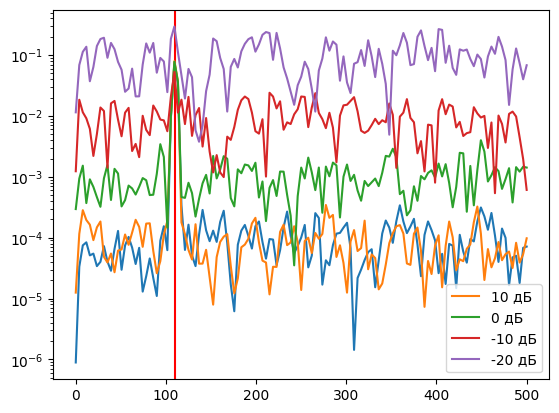

In [44]:
fs=1000
N=500
t=np.linspace(0,N/fs,N)
f_sig=110
A=1
x_clean = A * np.sin(2*np.pi*f_sig*t)

SNR_dB = 10
SNR_lin = 10**(SNR_dB/10)
P_sig = A**2/2
P_noise = P_sig / SNR_lin
noise = np.sqrt(P_noise) * np.random.randn(N)
x = x_clean + noise

f, P = welch(x, fs, nperseg=256, noverlap=128)

plt.semilogy(f, P)
plt.axvline(f_sig, color='r')
plt.grid()

for snr in [10, 0, -10, -20]:
    P_noise = P_sig / (10**(snr/10))
    x = x_clean + np.sqrt(P_noise)*np.random.randn(N)
    f, Pxx = welch(x, fs, nperseg=256)
    plt.semilogy(f, Pxx, label=f'{snr} дБ')
plt.legend()
plt.grid()
plt.show()

**Вопрос:** Как меняется видимость пика на спектре при изменении SNR? При каком SNR пик ещё можно уверенно обнаружить визуально?


{При уменьшении SNR пик на 110 Гц хуже выделяется на фоне шума. Шум растет, спекральный максимум уменьшается. Пик можно различить при -20 дБ, но он менее выразителен, чем при 10 и 0 дБ}

## Задание 7. Разрешение двух близких частот
Сгенерируйте сигнал, содержащий две синусоиды с частотами 100 и 110 Гц, равными амплитудами 1, и белый шум с дисперсией 0.1. Длительность сигнала 1 секунда, fs=1000 Гц. Используйте метод Уэлча с разными длинами сегмента: 128, 256, 512. Постройте оценки СПМ для каждого случая.


128: 7.81 Гц
256: 3.91 Гц
512: 1.95 Гц


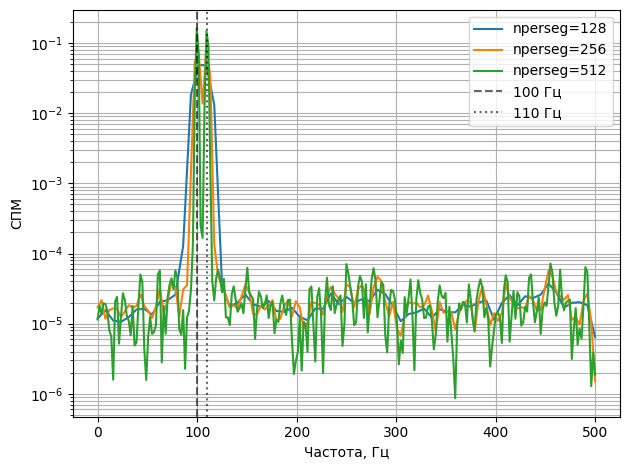

In [45]:
fs=1000
N=1000
f1, f2 = 100, 110
t = np.arange(N) / fs
sig = (A * np.sin(2 * np.pi * f1 * t) + A * np.sin(2 * np.pi * f2 * t))
x = sig + 0.1*np.random.randn(N)

for nseg in [128,256,512]:
    f, P = welch(x, fs, nperseg=nseg, noverlap=nseg//2, window='hann')
    plt.semilogy(f, P, label=f'nperseg={nseg}')
    df = fs / nseg
    print(f"{nseg:>3}: {df:.2f} Гц")

plt.axvline(f1, linestyle='--', color='black', alpha=0.6, label='100 Гц')
plt.axvline(f2, linestyle=':', color='black', alpha=0.6, label='110 Гц')

plt.xlabel('Частота, Гц')
plt.ylabel('СПМ')
plt.grid(True, which='both')
plt.legend()
plt.tight_layout()
plt.show()

**Вопрос:** При какой длине сегмента удаётся разделить две частоты? Сравните с грубой теоретической оценкой частотного разрешения $\Delta f \approx f_s / N_{seg}$.


{Разделение заметно на длине 256 и 512 и на 512 лучше. С теоретической оценкой согласуется}